In [1]:
# ----------------------------
# 1. Load and Embed Documents
# ----------------------------
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]
docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
vectorstore = FAISS.from_documents(
    chunks,
    HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
)
retriever = vectorstore.as_retriever()
print(f"Indexed {len(chunks)} chunks")



C:\Users\itsar\AppData\Local\Temp\ipykernel_34592\3283223647.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
c:\RAG\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8422.63it/s]


Indexed 234 chunks


In [2]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="groq:openai/gpt-oss-120b")
print("LLM ready")

LLM ready


In [5]:
# ----------------------------
# 2. State Schema
# ----------------------------
from langchain_core.documents import Document
from typing import List
from pydantic import BaseModel
class RAGState(BaseModel):
    question: str
    sub_questions: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [6]:
# ----------------------------
# 3. Nodes
# ----------------------------

## a. Query Planner: splits input question
def plan_query(state: RAGState) -> RAGState:
   
    prompt = f"""
Break the following complex question into 2-3 sub-questions:

Question: {state.question}

Sub-questions:
"""
    result = llm.invoke(prompt)
    sub_questions = [line.strip("- ").strip() for line in result.content.strip().split("\n") if line.strip()]
    return RAGState(question=state.question, sub_questions=sub_questions)

## b. Retrieve documents for each sub-question
def retrieve_for_each(state: RAGState) -> RAGState:
    all_docs = []
    for sub in state.sub_questions:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return RAGState(question=state.question, sub_questions=state.sub_questions, retrieved_docs=all_docs)

## c. Generate final answer
def generate_final_answer(state: RAGState) -> RAGState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
Use the context below to answer the question.

Context:
{context}

Question: {state.question}
"""
    
    answer = llm.invoke(prompt).content
    return RAGState(question=state.question, sub_questions=state.sub_questions, retrieved_docs=state.retrieved_docs, answer=answer)


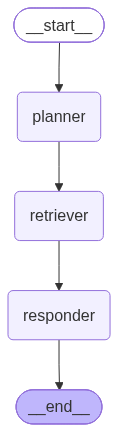

In [7]:
from langgraph.graph import StateGraph
# ----------------------------
# 4. Build LangGraph
from langgraph.constants import END
# ----------------------------
builder = StateGraph(RAGState)

builder.add_node("planner", plan_query)
builder.add_node("retriever", retrieve_for_each)
builder.add_node("responder", generate_final_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [8]:
# ----------------------------
# 5. Run the pipeline
# ----------------------------
if __name__ == "__main__":
    user_query = "Explain how agent loops work and what are the challenges in diffusion video generation?"
    initial_state = RAGState(question=user_query)
    final_state = graph.invoke(initial_state)
    print(final_state)

    print("\n🔍 Sub-questions:")
    for q in final_state['sub_questions']:
        print("-", q)

    print("\n✅ Final Answer:\n", final_state['answer'])

{'question': 'Explain how agent loops work and what are the challenges in diffusion video generation?', 'sub_questions': ['**Possible sub‑questions**', '1. **What is an agent loop, and what are its main components (perception, reasoning, planning, and actuation) and the flow of information between them?**', 'How does the loop iterate over time and adapt to new observations?', 'What role do feedback and memory play in maintaining a coherent loop?', '2. **How does a diffusion model generate video, and what are the key steps (noise schedule, conditioning, frame‑wise or spatio‑temporal diffusion) involved in the process?**', 'How are temporal dependencies modeled and enforced during generation?', '3. **What are the primary challenges faced when applying diffusion models to video generation?**', 'Computational cost and scalability to long sequences.', 'Maintaining temporal consistency and avoiding flickering or artifacts.', 'Handling high‑resolution frames, long‑range motion, and diverse co